In [ ]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

In [ ]:
'''
極座標生成2維常態

x, y ~ N(0,1)

x**2 + y ** 2 = R  。又等同於exp(1  2)

theta = uniform (0, 2pi)

生成R theta。便可由三角函數得出 (x, y)座標

'''

In [2]:
x = []
y = []


for i in range(10000):
    
    u = random.uniform(0, 1)
    
    r = -2 * np.log(u)
    
    theta = random.uniform(0, 2 * np.pi)
    
    x.append(r**0.5 * np.cos(theta))
    y.append(r**0.5 * np.sin(theta))

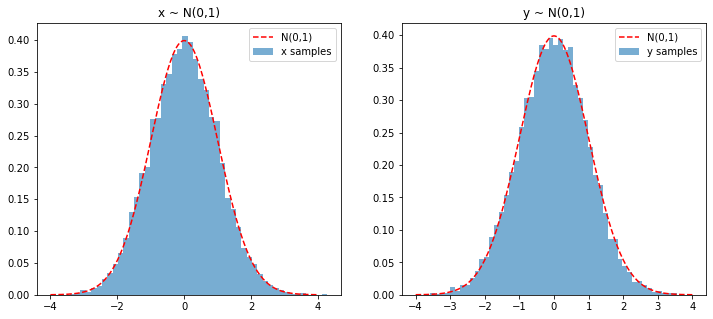

In [ ]:


# 畫直方圖與常態曲線
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(x, bins=50, density=True, alpha=0.6, label='x samples')
xs = np.linspace(-4, 4, 200)
plt.plot(xs, stats.norm.pdf(xs), 'r--', label='N(0,1)')
plt.title("x ~ N(0,1)")
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(y, bins=50, density=True, alpha=0.6, label='y samples')
plt.plot(xs, stats.norm.pdf(xs), 'r--', label='N(0,1)')
plt.title("y ~ N(0,1)")
plt.legend()

plt.show()

In [ ]:
#polar method: 接受拒絕法，較慢但不用三角函數

In [5]:
def polar_method(n):
    z0 = []
    z1 = []

    while len(z0) < n:
        u = np.random.uniform(-1, 1)
        v = np.random.uniform(-1, 1)
        s = u**2 + v**2 #圓

        if s == 0 or s >= 1: #拒絕圓外
            continue 

        factor = np.sqrt(-2 * np.log(s) / s) # r**2  = exp(1/2)
        z0.append(u * factor)
        z1.append(v * factor)

    return z0, z1

# 生成一萬個標準常態樣本
x, y = polar_method(10000)

In [ ]:
'''
有了 Z1 .... Zk 。

sigma Zk**2 == 卡方(k) also 可從exp(1/2)。 

'''

In [16]:
# 卡方2 == exp(1/2) == x**2 + y**2


x = np.array(x)
y = np.array(y)


z = x**2 + y **2


(array([5.940e+03, 2.422e+03, 9.560e+02, 4.240e+02, 1.440e+02, 6.500e+01,
        3.000e+01, 1.300e+01, 3.000e+00, 3.000e+00]),
 array([1.53560166e-04, 1.79879685e+00, 3.59744015e+00, 5.39608344e+00,
        7.19472673e+00, 8.99337002e+00, 1.07920133e+01, 1.25906566e+01,
        1.43892999e+01, 1.61879432e+01, 1.79865865e+01]),
 <BarContainer object of 10 artists>)

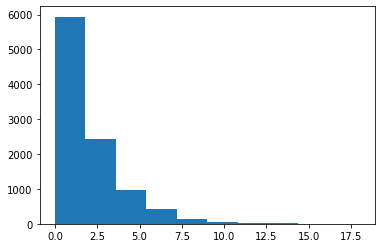

In [17]:
plt.hist(z)

In [18]:
z = []
for i in range(10000):
    z.append(-2* np.log(random.uniform(0,1)))

(array([6.915e+03, 2.089e+03, 6.900e+02, 2.200e+02, 6.600e+01, 1.300e+01,
        4.000e+00, 1.000e+00, 1.000e+00, 1.000e+00]),
 array([9.22330587e-05, 2.37320703e+00, 4.74632182e+00, 7.11943662e+00,
        9.49255141e+00, 1.18656662e+01, 1.42387810e+01, 1.66118958e+01,
        1.89850106e+01, 2.13581254e+01, 2.37312402e+01]),
 <BarContainer object of 10 artists>)

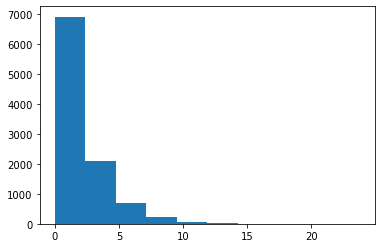

In [19]:
plt.hist(z)

In [ ]:
'''
multi nominal distribution(x1...xk) (n,p1...pk)

法1: 拆成2項分布


x1 ~ bin(n, pi1)

x2 = x2|x1  ~ bin(n - x1, pi2 / (1-pi1)) 沒有紅球了

.....

'''

In [ ]:
'''
poisson process(實際時間點)

失憶性 : 兩時點間為獨立 exp(lambda)。不受影響。


problem :沒有尖峰，離峰。
'''

In [20]:
#法一 生成exp

s = [0]
T = 10 


for i in range(10000):
    
    if s[-1] > 10:
        break
    
    u = random.uniform(0,1)
    t = s[-1] - (0.5*np.log(u))
    
    s.append(t)

In [21]:
s

[0,
 0.14346865019153013,
 2.649675375292851,
 3.6061546824550543,
 3.8366745975266556,
 5.578680713383732,
 7.907386614304338,
 8.050149325185284,
 8.905352878025855,
 9.567673475610231,
 10.300291642691736]

In [23]:
'''
拆分都是poisson，所以能直接生全部

'''
lam = 2  # λ intensity
T = 10   # total simulation time

# Step 1: 先生成總事件數
N = np.random.poisson(lam * T)

# Step 2: 生 N 個 Uniform(0, T) 的 U_i
U = np.random.uniform(0, T, size=N)

# Step 3: 按照大小排序 → 得到事件時間
event_times = np.sort(U)

print(f"事件總數 N = {N}")
print("事件時間點：", event_times)

事件總數 N = 15
事件時間點： [0.93560671 1.09697905 1.9195697  2.86421032 3.26092204 3.54339062
 3.79496758 4.32823571 5.66795677 6.57954111 7.95287157 8.28020206
 8.96028569 9.50985939 9.68264379]


In [ ]:
'''
nonhomogenous poisson

lambda 隨著時間改變

rejection method : 生很多，多餘的丟棄


透過先生成一個「包住」的 Homogeneous Poisson 過程（HP）然後用接受/拒絕機率將其「篩選」成你要的 非齊次過程（NHP）。

𝜆(𝑡)≤𝜆∗ 上界!!!!!


𝜆(𝑡) / 𝜆∗。越大越有機會留下來

'''

In [26]:
s = [0]
T = 10
I = 0
t = 0
while True:
    if t > T:
        break
        
    u1 = random.uniform(0,1)
    t = s[I] - ((1/7)*np.log(u1))
    u2 = random.uniform(0,1)
    if u2 <= (3+(4/(t+1)))/ 7:
        I += 1
        s.append(t)
    

In [ ]:

s1 = pd.Series(s)

In [31]:
s1

0     0.000000
1     0.062559
2     0.132470
3     0.485557
4     0.494618
        ...   
74    8.514229
75    8.673327
76    9.336539
77    9.483926
78    9.727985
Length: 79, dtype: float64

In [35]:
s2 = s1.cumsum()

In [36]:
s2

0       0.000000
1       0.062559
2       0.195029
3       0.680586
4       1.175204
         ...    
74    343.202793
75    351.876120
76    361.212659
77    370.696585
78    380.424569
Length: 79, dtype: float64

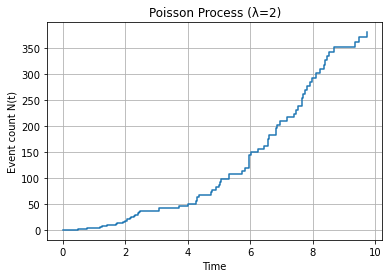

In [37]:
plt.step(s1, s2, where='post')
plt.xlabel("Time")
plt.ylabel("Event count N(t)")
plt.title("Poisson Process (λ=2)")
plt.grid(True)
plt.show()

In [ ]:
'''
驗證poisson process。每個區間段也應該是possion
這是最常用來驗證 NHPP 模擬是否正確的方法之一。


把模擬時間區間 [0,T] 切分成等長的子區間，例如每段長度為 

統計每個區段內的事件數。與該區間內的理論平均值（預期值）比較：


'''